# Data Mining Assignment 3 – Clustering and Anomaly Detection
## Task 3: Anomaly Detection

---
### 0. Import & Config

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os 
import json
import scipy 
import pickle
import re

from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import normalize
from sklearn.neighbors import NearestNeighbors
from sklearn.neighbors import LocalOutlierFactor
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

# paths creation need to adapt with yours
path = r'C:\Users\ephts\OneDrive\Documents\Master UA\Data mining\A3' 

data_path = os.path.join(path, 'datas')
preprocessed = os.path.join(path, 'preprocessed')
figures = os.path.join(path, 'fig')
final_path = os.path.join(path, 'final_output')

CLUSTERS_PATH = os.path.join(final_path,'clusters.csv')

print('Imported and paths created')

Imported and paths created


---
### 1. Loading preprocessed datas


In [41]:
X = scipy.sparse.load_npz(os.path.join(preprocessed, 'tfidf_matrix.npz'))

with open(os.path.join(preprocessed, 'vectorizer.pkl'), 'rb') as f:
    vectorizer = pickle.load(f)

article = pd.read_csv(os.path.join(preprocessed, 'article_clean.csv'))
article_orig = pd.read_csv(os.path.join(data_path, 'articles.csv'))

def repetition_ratio(text):
    words = text.lower().split()
    return 1 - len(set(words)) / len(words) if words else 0

def url_count(text):
    return len(re.findall(r'http\S+|www\S+', text))

article_orig['repetition_ratio'] = article_orig['text'].apply(repetition_ratio)
article_orig['url_count'] = article_orig['text'].apply(url_count)

print(f"Matrix loaded: {X.shape}")
print(f"Articles loaded: {len(article)}")

Matrix loaded: (2164, 5000)
Articles loaded: 2164


---
### 2. Dimensionality reduction

In [30]:
svd = TruncatedSVD(n_components=200, random_state=42)
X_lsa = svd.fit_transform(X)
X_lsa = normalize(X_lsa, norm='l2')

print(f"Reduced shape: {X_lsa.shape}")
print(f"Variance explained: {svd.explained_variance_ratio_.sum():.2%}")

Reduced shape: (2164, 200)
Variance explained: 33.33%


---
### 3. KNN Anomaly Detection

In [31]:
# Fit KNN with k=10 neighbors
k = 10
knn = NearestNeighbors(n_neighbors=k, metric='cosine')
knn.fit(X_lsa)

# Compute distance to k nearest neighbors for each document
distances, _ = knn.kneighbors(X_lsa)

# Anomaly score = mean distance to k neighbors
anomaly_scores = distances.mean(axis=1)

article['anomaly_score_knn'] = anomaly_scores

print(f"Anomaly scores computed for {len(anomaly_scores)} documents")
print(f"\nScore statistics:")
print(pd.Series(anomaly_scores).describe())

Anomaly scores computed for 2164 documents

Score statistics:
count    2164.000000
mean        0.478020
std         0.132427
min         0.003696
25%         0.441605
50%         0.513199
75%         0.562313
max         0.649512
dtype: float64


---
### 4. Anomaly scores visualization

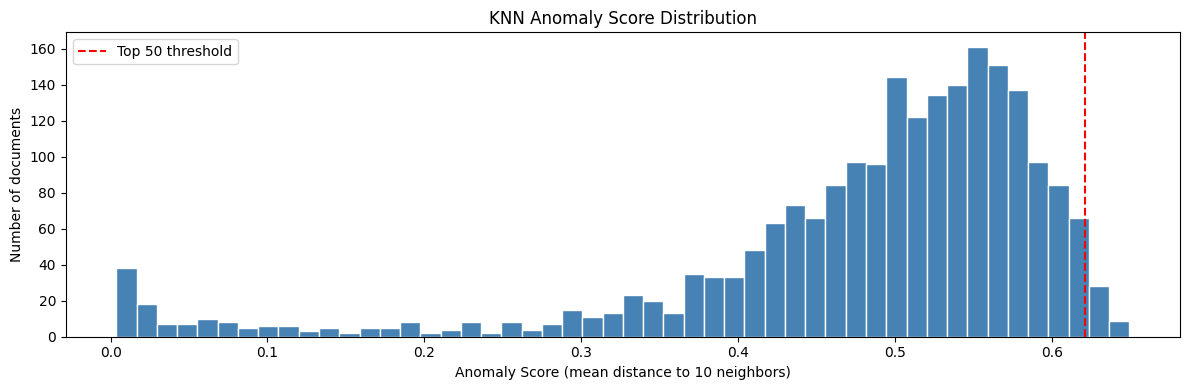

Threshold (top 50): 0.6215
Documents above threshold: 50


In [32]:
plt.figure(figsize=(12, 4))

plt.hist(anomaly_scores, bins=50, color='steelblue', edgecolor='white')
plt.axvline(x=np.percentile(anomaly_scores, 97.7),  # top 50/2164
            color='red', linestyle='--', 
            label='Top 50 threshold')
plt.xlabel('Anomaly Score (mean distance to 10 neighbors)')
plt.ylabel('Number of documents')
plt.title('KNN Anomaly Score Distribution')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(figures, 'knn_anomaly_scores.png'), dpi=150)
plt.show()

# Top 50 anomalies
threshold = np.percentile(anomaly_scores, 97.7)
print(f"Threshold (top 50): {threshold:.4f}")
print(f"Documents above threshold: {(anomaly_scores > threshold).sum()}")

---
### 5. LOF - Local Outlier Factor

In [33]:
lof = LocalOutlierFactor(n_neighbors=10, contamination=0.023)
lof_labels = lof.fit_predict(X_lsa)  # -1 = anomaly, 1 = normal

# LOF score (negative = more anomalous)
lof_scores = -lof.negative_outlier_factor_

article['anomaly_score_lof'] = lof_scores
article['anomaly_lof'] = lof_labels  # -1 or 1

n_anomalies = (lof_labels == -1).sum()
print(f"LOF anomalies detected: {n_anomalies}")
print(f"\nScore statistics:")
print(pd.Series(lof_scores).describe())

LOF anomalies detected: 50

Score statistics:
count    2164.000000
mean        1.034975
std         0.137731
min         0.975319
25%         1.000869
50%         1.010366
75%         1.024450
max         3.414718
dtype: float64


---
### 6. Visualization LOF scores

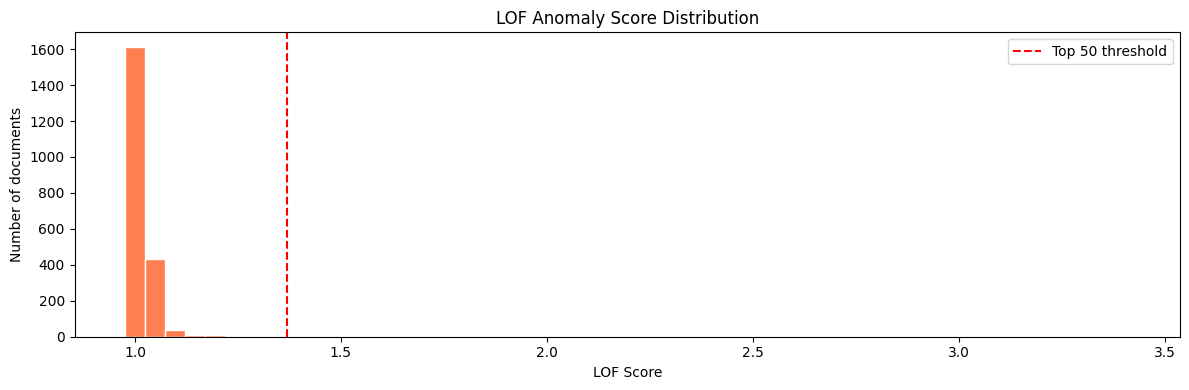


Top 10 most anomalous documents:
         doc_id  anomaly_score_lof
16    DOC_00017           3.414718
2070  DOC_02071           2.407388
606   DOC_00607           2.386705
465   DOC_00466           2.270032
2053  DOC_02054           2.238047
921   DOC_00922           2.197518
2047  DOC_02048           2.189276
479   DOC_00480           2.186979
2149  DOC_02150           2.149351
1198  DOC_01199           2.146956


In [34]:
plt.figure(figsize=(12, 4))
plt.hist(lof_scores, bins=50, color='coral', edgecolor='white')
plt.axvline(x=np.percentile(lof_scores, 97.7),
            color='red', linestyle='--', label='Top 50 threshold')
plt.xlabel('LOF Score')
plt.ylabel('Number of documents')
plt.title('LOF Anomaly Score Distribution')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(figures, 'lof_anomaly_scores.png'), dpi=150)
plt.show()

# Which documents are anomalies?
anomalies_lof = article[article['anomaly_lof'] == -1][['doc_id', 'anomaly_score_lof']]
print(f"\nTop 10 most anomalous documents:")
print(anomalies_lof.sort_values('anomaly_score_lof', ascending=False).head(10))

---
### 7. Isolation Forest

In [35]:
iso = IsolationForest(contamination=0.023, random_state=42)
iso_labels = iso.fit_predict(X_lsa)  # -1 = anomaly, 1 = normal
iso_scores = -iso.score_samples(X_lsa)  # higher = more anomalous

article['anomaly_score_iso'] = iso_scores
article['anomaly_iso'] = iso_labels

n_anomalies = (iso_labels == -1).sum()
print(f"Isolation Forest anomalies detected: {n_anomalies}")

print(f"\nTop 10 most anomalous documents:")
iso_anomalies = article[article['anomaly_iso'] == -1][['doc_id', 'anomaly_score_iso']]
print(iso_anomalies.sort_values('anomaly_score_iso', ascending=False).head(10))

Isolation Forest anomalies detected: 50

Top 10 most anomalous documents:
         doc_id  anomaly_score_iso
1294  DOC_01295           0.469926
94    DOC_00095           0.468454
1130  DOC_01131           0.467986
1467  DOC_01468           0.462003
1719  DOC_01720           0.459650
665   DOC_00666           0.457888
1137  DOC_01138           0.457546
1999  DOC_02000           0.456935
1932  DOC_01933           0.456573
1710  DOC_01711           0.455132


---
### 8. Compare the three methods

In [36]:
knn_top50 = set(article.nlargest(50, 'anomaly_score_knn')['doc_id'])
lof_anomalies = set(article[article['anomaly_lof'] == -1]['doc_id'])
iso_anomalies = set(article[article['anomaly_iso'] == -1]['doc_id'])

# Overlap between methods
print("Agreement between methods:")
print(f"  KNN ∩ LOF        : {len(knn_top50 & lof_anomalies)} docs in common")
print(f"  KNN ∩ ISO        : {len(knn_top50 & iso_anomalies)} docs in common")
print(f"  LOF ∩ ISO        : {len(lof_anomalies & iso_anomalies)} docs in common")
print(f"  KNN ∩ LOF ∩ ISO  : {len(knn_top50 & lof_anomalies & iso_anomalies)} docs in common")

Agreement between methods:
  KNN ∩ LOF        : 0 docs in common
  KNN ∩ ISO        : 4 docs in common
  LOF ∩ ISO        : 1 docs in common
  KNN ∩ LOF ∩ ISO  : 0 docs in common


---
### 9. Qualitative Analysis of Suspicious Clusters

In [37]:
# Load clusters
clusters = pd.read_csv(CLUSTERS_PATH)

# Merge with original articles
cluster7_docs = clusters[clusters['cluster'] == 7].merge(
    article_orig[['doc_id', 'text']], on='doc_id'
)

print(f"Cluster 7: {len(cluster7_docs)} documents\n")
for _, row in cluster7_docs.head(5).iterrows():
    print(f"--- {row['doc_id']} ---")
    print(row['text'][:300])
    print()

Cluster 7: 70 documents

--- DOC_00029 ---
The FDA, I believe. Rules say no blood or blood products donations from anyone who has been in a malarial area for 3 years. I was a platelet donor until my Thailand trip and my blood bank was very disappointed to find out they couldn't use me for 3 years. Not necessarily. The same rules may not appl

--- DOC_00041 ---
A brain abscess is an infection deep in the brain substance. It is hard to cure with antibiotics, since it gets walled off, and usually, it needs surgical drainage. -- ---------------------------------------------------------------------------- Gordon Banks N3JXP | "Skepticism is the chastity of the

--- DOC_00074 ---
30mg per day of propranolol is a homeopathic dose in migraine. If you got fatigued at that level, it is unlikely that you will tolerate enough beta blocker to help you. Probably a single nightime dose. We don't know how they work in migraine, but it probably has something to do with seratonin. -- --

--- DOC_00096 -

In [38]:
# Check cluster 5 documents
cluster5_docs = clusters[clusters['cluster'] == 5].merge(
    article_orig[['doc_id', 'text']], on='doc_id'
)

print(f"Cluster 5: {len(cluster5_docs)} documents\n")
for _, row in cluster5_docs.head(5).iterrows():
    print(f"--- {row['doc_id']} ---")
    print(row['text'][:400])
    print()

Cluster 5: 50 documents

--- DOC_00012 ---
LISTING_ID_007 Selling my camera, clean, located near Hasselt, price 450 EUR. selling because of upgrade. selling because of upgrade. original packaging not included. pickup preferred. minor signs of use. pickup preferred. stored indoors. Contact: seller.market@example.com or +32 428 37 76 29. Special listing {ITEM}, bonus voucher DEAL500, only 24 HOURS left. Marketplace ref {CODE}, contact SELLER

--- DOC_00081 ---
LISTING_ID_006 Second-hand laptop, excellent, collection in Hasselt, around 250 euro. well maintained. original packaging not included. pickup preferred. recently cleaned. Contact: market.listing@example.com or +32 497 44 41 41. fast deal fast deal fast deal fast deal fast deal fast deal fast deal fast deal fast deal fast deal fast deal fast deal fast deal bonus sale bonus sale bonus sale bonus sa

--- DOC_00105 ---
LISTING_ID_033 Selling my sofa, used, located near Hasselt, price 1200 EUR. cash on pickup. well maintained. well mai

---
### 11. Add structural features

In [47]:

def has_listing_id(text):
    return int(bool(re.search(r'LISTING_ID', text)))

def template_count(text):
    return len(re.findall(r'\{[A-Z]+\}', text))

def phone_count(text):
    return len(re.findall(r'\+32|\d{4}/\d{2}\.\d{2}\.\d{2}', text))

article_orig['has_listing_id'] = article_orig['text'].apply(has_listing_id)
article_orig['template_count'] = article_orig['text'].apply(template_count)
article_orig['phone_count'] = article_orig['text'].apply(phone_count)

spam_features = ['has_listing_id', 'template_count', 
                 'phone_count', 'url_count', 'repetition_ratio']


print(article_orig[spam_features].describe())

       has_listing_id  template_count  phone_count    url_count  \
count     2164.000000      2164.00000  2164.000000  2164.000000   
mean         0.023105         0.17098     0.023105     0.191774   
std          0.150273         1.99453     0.150273     2.177026   
min          0.000000         0.00000     0.000000     0.000000   
25%          0.000000         0.00000     0.000000     0.000000   
50%          0.000000         0.00000     0.000000     0.000000   
75%          0.000000         0.00000     0.000000     0.000000   
max          1.000000        28.00000     1.000000    29.000000   

       repetition_ratio  
count       2164.000000  
mean           0.250273  
std            0.123921  
min            0.000000  
25%            0.166667  
50%            0.236292  
75%            0.311475  
max            0.890295  


---
### 12. Redo LOF + Isolation Forest on combined features

In [43]:
struct = article_orig.set_index('doc_id').loc[article['doc_id']]
spam_matrix = struct[spam_features].values

scaler = StandardScaler()
spam_scaled = scaler.fit_transform(spam_matrix)

# KNN
knn_spam = NearestNeighbors(n_neighbors=10, metric='euclidean')
knn_spam.fit(spam_scaled)
distances_spam, _ = knn_spam.kneighbors(spam_scaled)
knn_spam_scores = distances_spam.mean(axis=1)
knn_spam_ids = set(article.iloc[np.argsort(knn_spam_scores)[-50:]]['doc_id'])

# LOF
lof_spam = LocalOutlierFactor(n_neighbors=10, contamination=0.023)
lof_spam_labels = lof_spam.fit_predict(spam_scaled)
lof_spam_ids = set(article[lof_spam_labels == -1]['doc_id'])

# Isolation Forest
iso_spam = IsolationForest(contamination=0.023, random_state=42)
iso_spam_labels = iso_spam.fit_predict(spam_scaled)
iso_spam_ids = set(article[iso_spam_labels == -1]['doc_id'])

print(f"KNN detected  : {len(knn_spam_ids)}")
print(f"LOF detected  : {len(lof_spam_ids)}")
print(f"ISO detected  : {len(iso_spam_ids)}")
print(f"All 3 agree   : {len(knn_spam_ids & lof_spam_ids & iso_spam_ids)}")

C:\Users\ephts\OneDrive\Documents\Master UA\Data Mining\env\lib\site-packages\sklearn\neighbors\_lof.py:322: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


KNN detected  : 50
LOF detected  : 50
ISO detected  : 50
All 3 agree   : 0


---
### 13. Qualitative check - All methods ?

In [44]:

for method_name, ids in [('KNN', knn_spam_ids), 
                          ('LOF', lof_spam_ids), 
                          ('ISO', iso_spam_ids)]:
    docs = article_orig[article_orig['doc_id'].isin(ids)]
    print(f"\n{'='*50}")
    print(f"{method_name} - sample of detected anomalies")
    print('='*50)
    for _, row in docs.head(3).iterrows():
        print(f"\n--- {row['doc_id']} ---")
        print(row['text'][:300])
        print()


KNN - sample of detected anomalies

--- DOC_00012 ---
LISTING_ID_007 Selling my camera, clean, located near Hasselt, price 450 EUR. selling because of upgrade. selling because of upgrade. original packaging not included. pickup preferred. minor signs of use. pickup preferred. stored indoors. Contact: seller.market@example.com or +32 428 37 76 29. Speci


--- DOC_00089 ---
AHL CALDER CUP PLAYOFF GAME(S) PLAYED ON 4/16 Providence 3 SPRINGFIELD 2 (OT) Baltimore 4 BINGHAMTON 3 Utica 3 ROCHESTER 2 (OT) Cape Breton 5 FREDERICTON 2 GAME(S) SCHEDULED FOR 4/17 Capital District at Adirondack Providence at Springfield Baltimore at Binghamton Utica at Rochester Moncton vs St Joh


--- DOC_00098 ---
GAME(S) OF 4/15 --------------- ADIRONDACK 6 CDI 2 (Adirondack leads series, 1-0) ================================================= FIRST ROUND Springfield Indians vs Providence Bruins Gm 1: Springfield 3 PROVIDENCE 2 Gm 2: Springfield 5 PROVIDENCE 4 Gm 3: 4/16 Providence at Springfield Gm 4: 4/17 P




In [45]:

iso_docs = article_orig[article_orig['doc_id'].isin(iso_spam_ids)]

print(f"ISO anomalies: {len(iso_docs)} documents\n")
for _, row in iso_docs.iterrows():
    print(f"--- {row['doc_id']} ---")
    print(row['text'][:200])
    print()

ISO anomalies: 50 documents

--- DOC_00012 ---
LISTING_ID_007 Selling my camera, clean, located near Hasselt, price 450 EUR. selling because of upgrade. selling because of upgrade. original packaging not included. pickup preferred. minor signs of 

--- DOC_00081 ---
LISTING_ID_006 Second-hand laptop, excellent, collection in Hasselt, around 250 euro. well maintained. original packaging not included. pickup preferred. recently cleaned. Contact: market.listing@exam

--- DOC_00105 ---
LISTING_ID_033 Selling my sofa, used, located near Hasselt, price 1200 EUR. cash on pickup. well maintained. well maintained. selling because of upgrade. Contact: usedgoods.reply@example.com or 0492/6

--- DOC_00146 ---
LISTING_ID_038 Second-hand sofa, good condition, collection in Bruges, around 120 euro. works perfectly. well maintained. pickup preferred. battery included. kept in good shape. stored indoors. Contac

--- DOC_00211 ---
LISTING_ID_049 Second-hand phone, clean, collection in Brussels, around 6

---
### 14. Save anomalie.csv 



In [46]:
anomalies_output = pd.DataFrame({
    'doc_id': sorted(iso_spam_ids)
})

anomalies_output.to_csv(os.path.join(final_path, 'anomalies.csv'), index=False)


print(f"anomalies.csv saved — {len(anomalies_output)} documents")
print(anomalies_output)

anomalies.csv saved — 50 documents
       doc_id
0   DOC_00012
1   DOC_00081
2   DOC_00105
3   DOC_00146
4   DOC_00211
5   DOC_00215
6   DOC_00296
7   DOC_00314
8   DOC_00341
9   DOC_00359
10  DOC_00390
11  DOC_00416
12  DOC_00451
13  DOC_00473
14  DOC_00501
15  DOC_00576
16  DOC_00642
17  DOC_00677
18  DOC_00707
19  DOC_00879
20  DOC_00881
21  DOC_00883
22  DOC_01048
23  DOC_01069
24  DOC_01136
25  DOC_01208
26  DOC_01246
27  DOC_01254
28  DOC_01267
29  DOC_01405
30  DOC_01435
31  DOC_01451
32  DOC_01453
33  DOC_01470
34  DOC_01525
35  DOC_01555
36  DOC_01565
37  DOC_01585
38  DOC_01650
39  DOC_01698
40  DOC_01743
41  DOC_01752
42  DOC_01808
43  DOC_01902
44  DOC_01928
45  DOC_01983
46  DOC_02034
47  DOC_02050
48  DOC_02118
49  DOC_02140


---
### 15. ISO visualization

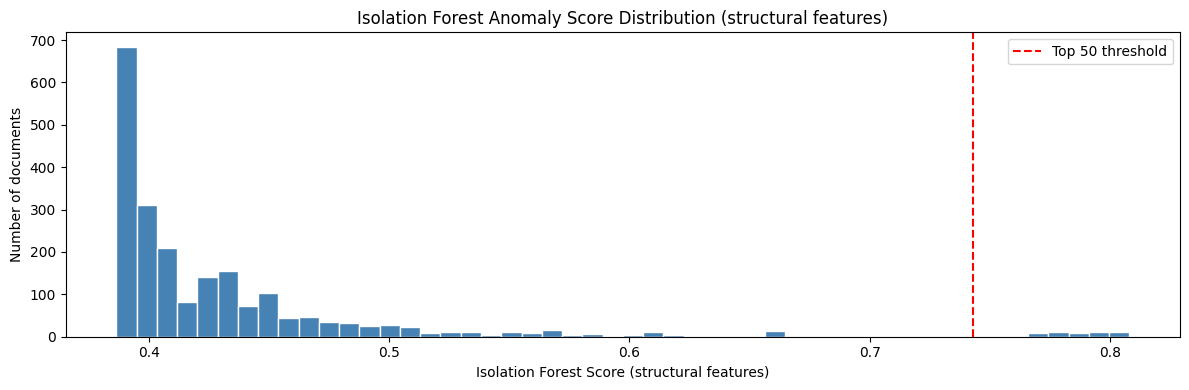

In [51]:
iso_spam_scores = -iso_spam.score_samples(spam_scaled)
plt.figure(figsize=(12, 4))
plt.hist(iso_spam_scores, bins=50, color='steelblue', edgecolor='white')
plt.axvline(x=np.percentile(iso_spam_scores, 97.7),
            color='red', linestyle='--', label='Top 50 threshold')
plt.xlabel('Isolation Forest Score (structural features)')
plt.ylabel('Number of documents')
plt.title('Isolation Forest Anomaly Score Distribution (structural features)')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(figures, 'iso_spam_scores.png'), dpi=150)
plt.show()